In [1]:
import pandas as pd



loan_data = {

    "Loan_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],

    "Gender": ["Male", "female", "M", "Male", None,

               "Female", "male", "F", "Male", "Female"],

    "Age": [25, 32, None, 28, 35, 40, 150, 50, 38, None],

    "Income": [25000, 40000, 60000, None, 45000,


               55000, 32000, 75000, "unknown", 28000],

    "Loan_Amount": [100000, 150000, 250000, 120000, None,

                    200000, 110000, 300000, 220000, 90000],

    "Credit_Score": [650, 720, 780, 600, 700,

                     None, 620, 800, 710, 1200],

    "Loan_Status": ["Approved", "approved", "APPROVED", "Rejected",

                    "Approved", None, "reject", "Approved",

                    "Rejected", "Approved "]

}



df = pd.DataFrame(loan_data)



print(df)

# 1 M, F , and non , Data inconsistensisty
#2 outlire
#3
#4 income in inconsistensisty data
# Loan -- Inconsistey data ,
# credit score missing and invalid data

   Loan_ID  Gender    Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101    Male   25.0    25000     100000.0         650.0    Approved
1      102  female   32.0    40000     150000.0         720.0    approved
2      103       M    NaN    60000     250000.0         780.0    APPROVED
3      104    Male   28.0     None     120000.0         600.0    Rejected
4      105    None   35.0    45000          NaN         700.0    Approved
5      106  Female   40.0    55000     200000.0           NaN        None
6      107    male  150.0    32000     110000.0         620.0      reject
7      108       F   50.0    75000     300000.0         800.0    Approved
8      109    Male   38.0  unknown     220000.0         710.0    Rejected
9      110  Female    NaN    28000      90000.0        1200.0   Approved 


In [3]:
null_percentage = (df.isnull())
print(null_percentage)

   Loan_ID  Gender    Age  Income  Loan_Amount  Credit_Score  Loan_Status
0    False   False  False   False        False         False        False
1    False   False  False   False        False         False        False
2    False   False   True   False        False         False        False
3    False   False  False    True        False         False        False
4    False    True  False   False         True         False        False
5    False   False  False   False        False          True         True
6    False   False  False   False        False         False        False
7    False   False  False   False        False         False        False
8    False   False  False   False        False         False        False
9    False   False   True   False        False         False        False


In [4]:
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

Loan_ID          0.0
Gender          10.0
Age             20.0
Income          10.0
Loan_Amount     10.0
Credit_Score    10.0
Loan_Status     10.0
dtype: float64


In [10]:
df['Gender']=df["Gender"].replace({
    'M':'Male',
    'F':'Female',
    'male':'Male',
    'female':'Female',
    'Unknown':'Female',
    'unknown':'Female',
    'None' : 'Female'
})
print(df['Gender'])

0      Male
1    Female
2      Male
3      Male
4      None
5    Female
6      Male
7    Female
8      Male
9    Female
Name: Gender, dtype: object


In [12]:
df['Income']=df['Income'].replace({
    'unknown':0,
    'Unknown':0,
    'none':0,
    'None':0,
    '0':0,
    '0.0':0,
    'Nan':0
})
print(df['Income'])

0    25000.0
1    40000.0
2    60000.0
3        NaN
4    45000.0
5    55000.0
6    32000.0
7    75000.0
8        0.0
9    28000.0
Name: Income, dtype: float64


In [13]:
df['Loan_Status']=df['Loan_Status'].str.upper()
print(df['Loan_Status'])

0     APPROVED
1     APPROVED
2     APPROVED
3     REJECTED
4     APPROVED
5         None
6       REJECT
7     APPROVED
8     REJECTED
9    APPROVED 
Name: Loan_Status, dtype: object


In [15]:
m=df['Income'].mean()
df['Income'].fillna(m,inplace=True)
print(df)

   Loan_ID  Gender    Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101    Male   25.0  25000.0     100000.0         650.0    APPROVED
1      102  Female   32.0  40000.0     150000.0         720.0    APPROVED
2      103    Male    NaN  60000.0     250000.0         780.0    APPROVED
3      104    Male   28.0  40000.0     120000.0         600.0    REJECTED
4      105    None   35.0  45000.0          NaN         700.0    APPROVED
5      106  Female   40.0  55000.0     200000.0           NaN        None
6      107    Male  150.0  32000.0     110000.0         620.0      REJECT
7      108  Female   50.0  75000.0     300000.0         800.0    APPROVED
8      109    Male   38.0      0.0     220000.0         710.0    REJECTED
9      110  Female    NaN  28000.0      90000.0        1200.0   APPROVED 


/tmp/ipykernel_780/241901198.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(m,inplace=True)


In [18]:
df['Credit_Score'].fillna(df['Credit_Score'].mean(),inplace=True)
print(df['Credit_Score'])

0     650.000000
1     720.000000
2     780.000000
3     600.000000
4     700.000000
5     753.333333
6     620.000000
7     800.000000
8     710.000000
9    1200.000000
Name: Credit_Score, dtype: float64


/tmp/ipykernel_780/1768818074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_Score'].fillna(df['Credit_Score'].mean(),inplace=True)


In [21]:
df["Loan_Amount"]=df["Loan_Amount"].fillna(df["Loan_Amount"].mean().round())
print(df['Loan_Amount'])

0    100000.0
1    150000.0
2    250000.0
3    120000.0
4    171111.0
5    200000.0
6    110000.0
7    300000.0
8    220000.0
9     90000.0
Name: Loan_Amount, dtype: float64


### What does the `object` data type mean in Pandas?

When pandas displays a column's data type as **`object`** (often abbreviated as `O`), it usually means one of the following:

1. **Text/Strings:** Columns containing text like names, categories, or status (e.g., your `Gender` and `Loan_Status` columns).
2. **Mixed Types:** Columns containing a mix of integers, floats, strings, or even Python lists/dictionaries.
3. **Python Objects:** If a column has `None` or mixed missing representations, pandas defaults to the generic `object` dtype to keep them compatible.

Let's check the data types of all columns in your current DataFrame to see this in action.

In [ ]:
# Check the data types of your DataFrame columns
print(df.dtypes)

In [20]:
df["Loan_Amount"].fillna(df["Loan_Amount"].mean().round(),inplace=True)
print(df['Loan_Amount'])

0    100000.0
1    150000.0
2    250000.0
3    120000.0
4    171111.0
5    200000.0
6    110000.0
7    300000.0
8    220000.0
9     90000.0
Name: Loan_Amount, dtype: float64


/tmp/ipykernel_780/2062084538.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Loan_Amount"].fillna(df["Loan_Amount"].mean().round(),inplace=True)


In [22]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
print(df["Income"])

0    25000.0
1    40000.0
2    60000.0
3    40000.0
4    45000.0
5    55000.0
6    32000.0
7    75000.0
8        0.0
9    28000.0
Name: Income, dtype: float64


In [24]:
mean_income = df['Income'].mean()

In [26]:
df['Income'] = df['Income'].fillna(mean_income)
print(df['Income'])

0    25000.0
1    40000.0
2    60000.0
3    40000.0
4    45000.0
5    55000.0
6    32000.0
7    75000.0
8        0.0
9    28000.0
Name: Income, dtype: float64


In [27]:
nums_cols=df.select_dtypes(include="number").columns

print(nums_cols)



for i in nums_cols:

  df[i]=df[i].fillna(df[i].mean())

Index(['Loan_ID', 'Age', 'Income', 'Loan_Amount', 'Credit_Score'], dtype='object')


In [29]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")





nums_cols = df.select_dtypes(include="number").columns





for i in nums_cols:

    df[i] = df[i].fillna(df[i].mean())



print(df.isna().sum())

print(df)

Loan_ID         0
Gender          1
Age             0
Income          0
Loan_Amount     0
Credit_Score    0
Loan_Status     1
dtype: int64
   Loan_ID  Gender     Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101    Male   25.00  25000.0     100000.0    650.000000    APPROVED
1      102  Female   32.00  40000.0     150000.0    720.000000    APPROVED
2      103    Male   49.75  60000.0     250000.0    780.000000    APPROVED
3      104    Male   28.00  40000.0     120000.0    600.000000    REJECTED
4      105    None   35.00  45000.0     171111.0    700.000000    APPROVED
5      106  Female   40.00  55000.0     200000.0    753.333333        None
6      107    Male  150.00  32000.0     110000.0    620.000000      REJECT
7      108  Female   50.00  75000.0     300000.0    800.000000    APPROVED
8      109    Male   38.00      0.0     220000.0    710.000000    REJECTED
9      110  Female   49.75  28000.0      90000.0   1200.000000   APPROVED 


In [31]:
#df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
nums_cols = df.select_dtypes(include="object").columns
for i in nums_cols:

    df[i] = df[i].fillna(df[i].mode())

#print(df.isna().sum())

print(df)

Loan_ID         0
Gender          1
Age             0
Income          0
Loan_Amount     0
Credit_Score    0
Loan_Status     1
dtype: int64
   Loan_ID  Gender     Age   Income  Loan_Amount  Credit_Score Loan_Status
0      101    Male   25.00  25000.0     100000.0    650.000000    APPROVED
1      102  Female   32.00  40000.0     150000.0    720.000000    APPROVED
2      103    Male   49.75  60000.0     250000.0    780.000000    APPROVED
3      104    Male   28.00  40000.0     120000.0    600.000000    REJECTED
4      105     NaN   35.00  45000.0     171111.0    700.000000    APPROVED
5      106  Female   40.00  55000.0     200000.0    753.333333         NaN
6      107    Male  150.00  32000.0     110000.0    620.000000      REJECT
7      108  Female   50.00  75000.0     300000.0    800.000000    APPROVED
8      109    Male   38.00      0.0     220000.0    710.000000    REJECTED
9      110  Female   49.75  28000.0      90000.0   1200.000000   APPROVED 


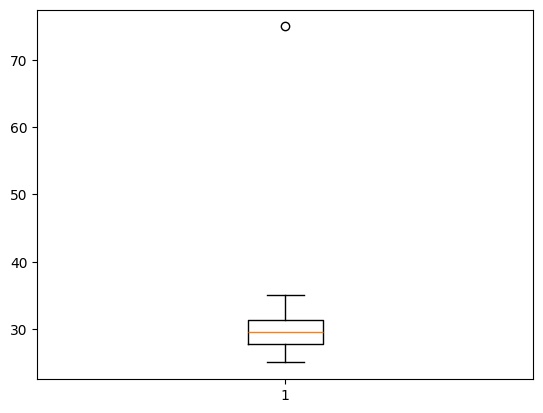

In [32]:
import pandas as pd

import matplotlib.pyplot as plt

data = {

    "Employee": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J",

                 "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"],

    "Age": [25, 27, 29, 31, 28, 35, 32, 30, 26, 29,

            33, 31, 28, 27, 30, 34, 29, 26, 75, 31],

    "Experience": [1, 2, 3, 5, 3, 8, 7, 6, 2, 4,

                   9, 5, 3, 2, 6, 8, 4, 1, 40, 5],

    "Salary": [25000, 28000, 30000, 32000, 29000, 45000, 42000, 38000, 27000, 31000,

               48000, 35000, 30000, 28000, 40000, 46000, 33000, 26000, 250000, 34000],

    "Projects": [2, 3, 4, 5, 3, 8, 7, 6, 2, 4,

                 9, 5, 4, 3, 6, 8, 5, 2, 50, 5]

}

df = pd.DataFrame(data)

plt.boxplot(df["Age"])

plt.show()

#print(df)

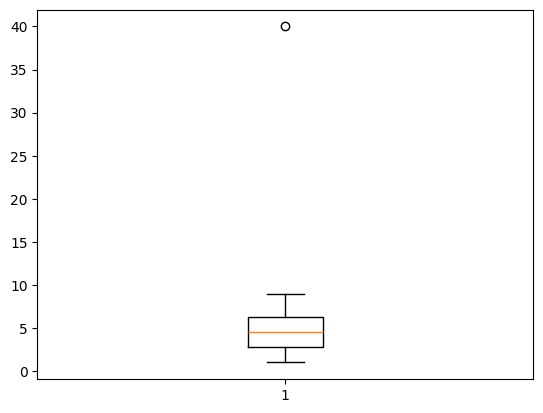

In [34]:

df = pd.DataFrame(data)

plt.boxplot(df["Experience"])

plt.show()

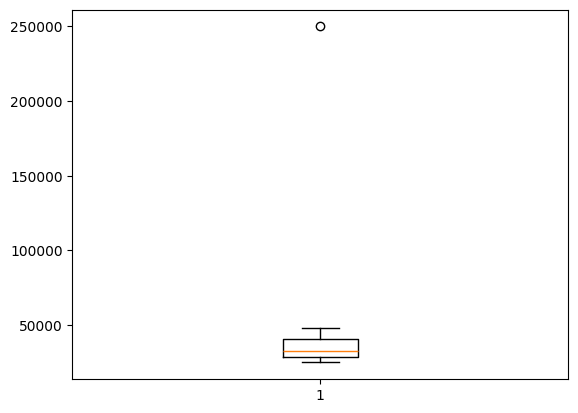

In [35]:
df = pd.DataFrame(data)

plt.boxplot(df["Salary"])

plt.show()

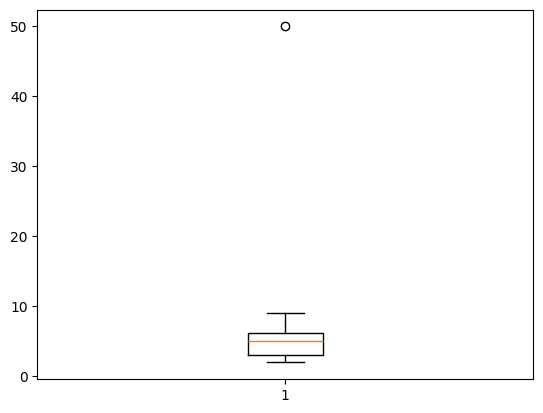

In [36]:
df = pd.DataFrame(data)

plt.boxplot(df["Projects"])

plt.show()

In [37]:
#print(df)

# Q1

# Q3

# IQR = Q3-Q1

# lower =Q1-1.5*IQR

#upper= Q3+1.5*IQR

q1=df["Salary"].quantile(0.25)

q3=df["Salary"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Salary"] < lower) | (df["Salary"] > upper)])

   Employee  Age  Experience  Salary  Projects
18        S   75          40  250000        50


In [38]:
q1=df["Projects"].quantile(0.25)

q3=df["Projects"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Projects"] < lower) | (df["Projects"] > upper)])

   Employee  Age  Experience  Salary  Projects
18        S   75          40  250000        50


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Employee": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J",
                 "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"],
    "Age": [25, 27, 29, 31, 28, 35, 75, 30, 26, 29,
            33, 31, 28, 27, 30, 34, 29, 26, 31, 32], # Added 32 to make it 20 elements
    "Experience": [1, 2, 3, 5, 3, 8, 7, 6, 2, 4,
                   9, 5, 3, 2, 6, 8, 4, 1, 40, 5], # Already 20 elements
    "Salary": [250000, 28000, 30000, 32000, 29000, 45000, 42000, 38000, 27000, 31000,
               48000, 35000, 30000, 28000, 40000, 46000, 33000, 26000, 34000, 35000], # Added 35000 to make it 20 elements
    "Projects": [2, 3, 4, 5, 3, 8, 7, 6, 2, 4,
                 9, 5, 4, 3, 6, 8, 5, 2, 5, 50] # Already 20 elements
}

df = pd.DataFrame(data)

q1=df["Projects"].quantile(0.25)

q3=df["Projects"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Projects"] < lower) | (df["Projects"] > upper)])

   Employee  Age  Experience  Salary  Projects
19        T   32           5   35000        50


In [44]:
q1=df["Salary"].quantile(0.25)

q3=df["Salary"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Salary"] < lower) | (df["Salary"] > upper)])

  Employee  Age  Experience  Salary  Projects
0        A   25           1  250000         2


In [45]:
q1=df["Experience"].quantile(0.25)

q3=df["Experience"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Experience"] < lower) | (df["Experience"] > upper)])

   Employee  Age  Experience  Salary  Projects
18        S   31          40   34000         5


In [46]:
q1=df["Age"].quantile(0.25)

q3=df["Age"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Age"] < lower) | (df["Age"] > upper)])

  Employee  Age  Experience  Salary  Projects
6        G   75           7   42000         7


In [47]:
import pandas as pd

import matplotlib.pyplot as plt

data = {

    "Item": [

        "Item1", "Item2", "Item3", "Item4", "Item5",

        "Item6", "Item7", "Item8", "Item9", "Item10",

        "Item11", "Item12", "Item13", "Item14", "Item15",

        "Item16", "Item17", "Item18", "Item19", "Item20",

        "Item21", "Item22", "Item23", "Item24", "Item25",

        "Item26", "Item27", "Item28", "Item29", "Item30"

    ],



    "Sales": [

        45000, 52000, 48000, 61000, 55000,

        47000, 58000, 63000, 51000, 59000,

        54000, 62000, 57000, 49000, 53000,

        60000, 56000, 64000, 50000, 68000,

        43000, 65000, 47000, 72000, 55000,

        2000, 5000, 8000, 350000, 500000

    ]

}



df = pd.DataFrame(data)



print(df)

      Item   Sales
0    Item1   45000
1    Item2   52000
2    Item3   48000
3    Item4   61000
4    Item5   55000
5    Item6   47000
6    Item7   58000
7    Item8   63000
8    Item9   51000
9   Item10   59000
10  Item11   54000
11  Item12   62000
12  Item13   57000
13  Item14   49000
14  Item15   53000
15  Item16   60000
16  Item17   56000
17  Item18   64000
18  Item19   50000
19  Item20   68000
20  Item21   43000
21  Item22   65000
22  Item23   47000
23  Item24   72000
24  Item25   55000
25  Item26    2000
26  Item27    5000
27  Item28    8000
28  Item29  350000
29  Item30  500000


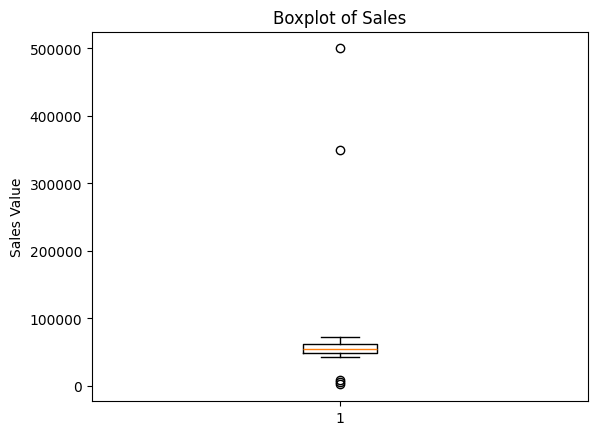

In [49]:
df = pd.DataFrame(data)
plt.boxplot(df["Sales"])
plt.title("Boxplot of Sales")
plt.ylabel("Sales Value")
plt.show()

In [50]:
q1=df["Sales"].quantile(0.25)

q3=df["Sales"].quantile(0.75)

IQR = q3-q1

lower =q1-1.5*IQR

upper= q3+1.5*IQR

print(df[(df["Sales"] < lower) | (df["Sales"] > upper)])


      Item   Sales
25  Item26    2000
26  Item27    5000
27  Item28    8000
28  Item29  350000
29  Item30  500000


In [ ]:
# 1. Define the outlier filter condition first
outliers_filter = (df["Sales"] < lower) | (df["Sales"] > upper)

# 2. To show ONLY the 'Item' column for these outliers:
print("--- Outlier Items Only ---")
print(df.loc[outliers_filter, "Item"])

# 3. To show ONLY the 'Sales' column for these outliers:
print("\n--- Outlier Sales Only ---")
print(df.loc[outliers_filter, "Sales"])

# 4. To show both side-by-side but as a DataFrame:
print("\n--- Outlier Items and Sales side-by-side ---")
display(df.loc[outliers_filter, ["Item", "Sales"]])

In [52]:
# Calculate IQR and threshold bounds first
q1 = df["Sales"].quantile(0.25)
q3 = df["Sales"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

# Define the outlier filter
outliers_filter = (df["Sales"] < lower) | (df["Sales"] > upper)

# Display only the 'Item' column for these outliers
print(df.loc[outliers_filter, "Item"])

25    Item26
26    Item27
27    Item28
28    Item29
29    Item30
Name: Item, dtype: object
